# **Data Preparation and Analysis of Major Crime Indicator Dataset**

 **Summary:**

**1. Data preparation by report date**

*   Select records for 2021 to 2024 and sort by REPORT_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: REPORT_MONTH_SEQ
*   Create column: REPORT_DAY_SEQ
*   Create column: REPORT_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, WEEK_SEQ
*   Group crime counts by HOOD_158, WEEK_SEQ, MCI_CATEGORY

**2. Data preparation by occurence date**

*   Select records for 2021 to 2024 and sort by OCC_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: OCC_MONTH_SEQ
*   Create column: OCC_DAY_SEQ
*   Create column: OCC_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ, OCC_MCI_CATEGORY

**3. Create a column: HOLIDAY and anlysis of holiday vs non holiday by occurence date**

**4. Create a column: WEEKEND and anlysis of weekday vs weekends by occurence date**

**5. Anlysis of day time vs night time by occurence date**

**6. Anlysis of PREMISES_TYPE by occurence date**

**7. Anlysis of LOCATION_TYPE by occurence date**

**8. Anlysis of OFFENCE by occurence date**

**9. Analysis by report date**

**10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**



In [2]:
# Dynamically choose file from repository
from google.colab import files
uploaded = files.upload()

MessageError: TypeError: can't access property "next", steps is undefined

In [1]:
#Load the initial dataset into dataframe
import pandas as pd
import io

df = pd.read_csv('Major_Crime_Indicators_Open_Data_-3805566126367379926.csv')
df.shape

(430614, 31)

## **1. Data preparation by report date**

In [2]:
# Make a copy of the original dataset for process data and keeping the original data integrity
df_mci = df.copy()
#Select records for years 2021 - 2024, sort by REPORT_DATE
df_mci = df_mci[(df_mci['REPORT_YEAR'] >= 2021) &
      (df_mci['REPORT_YEAR'] < 2025)]
df_mci.sort_values(by='REPORT_DATE', ascending=True)
df_mci.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
420489,420490,GO-20242821061,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,22,...,Robbery With Weapon,Robbery,126,Dorset Park (126),126,Dorset Park (126),-79.273631,43.745996,-8.824700e+06,5.426218e+06
420490,420491,GO-20242819772,12/31/2024 5:00:00 AM,12/30/2024 5:00:00 AM,2024,December,31,366,Tuesday,18,...,Assault,Assault,108,Briar Hill-Belgravia (108),108,Briar Hill-Belgravia (108),-79.440599,43.701073,-8.843287e+06,5.419298e+06
420491,420492,GO-20242820426,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,20,...,Assault With Weapon,Assault,033,Clanton Park (33),033,Clanton Park (33),-79.449706,43.734062,-8.844301e+06,5.424380e+06
420492,420493,GO-20242814702,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,1,...,Theft Of Motor Vehicle,Auto Theft,002,Mount Olive-Silverstone-Jamestown (2),002,Mount Olive-Silverstone-Jamestown (2),-79.585776,43.750942,-8.859448e+06,5.426980e+06
420493,420494,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420494,420495,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420495,420496,GO-20242816566,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,12,...,Theft Over,Theft Over,009,Edenbridge-Humber Valley (9),009,Edenbridge-Humber Valley (9),-79.524582,43.672837,-8.852636e+06,5.414952e+06
420496,420497,GO-20242817087,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,14,...,B&E,Break and Enter,084,Little Portugal (84),084,Little Portugal (84),-79.423596,43.643234,-8.841394e+06,5.410397e+06
420497,420498,GO-20242818018,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,13,...,Assault,Assault,029,Maple Leaf (29),029,Maple Leaf (29),-79.478591,43.711185,-8.847516e+06,5.420856e+06
420498,420499,GO-20242815101,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,3,...,Theft Of Motor Vehicle,Auto Theft,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),-79.401983,43.647598,-8.838988e+06,5.411068e+06


In [3]:
df_mci.shape

(173820, 31)

In [4]:
df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]

np.int64(246904)

In [5]:
last_index = df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]
last_index

np.int64(420245)

In [6]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci = df_mci.loc[(df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]) : df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]]
df_mci.shape

(173342, 31)

In [7]:
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Theft Over,Theft Over,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,B&E,Break and Enter,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,B&E,Break and Enter,097,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Theft Of Motor Vehicle,Auto Theft,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,B&E,Break and Enter,173,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,Assault,Assault,049,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,B&E,Break and Enter,128,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,Assault With Weapon,Assault,036,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,B&E,Break and Enter,144,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06


In [8]:
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)

/tmp/ipython-input-8-1020389931.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [9]:
#Create a column DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
from datetime import datetime
df_mci['DAY_SEQ'] = pd.to_datetime(df_mci["REPORT_MONTH_SEQ"].astype(str) + "/" + df_mci["REPORT_DAY"].astype(str) + "/" + df_mci["REPORT_YEAR"].astype(str))
df_mci['DAY_SEQ'] = (df_mci['DAY_SEQ'] - df_mci['DAY_SEQ'].iloc[0]).dt.days
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,141,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,097,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,173,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,049,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06,12,1455
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,128,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06,12,1455
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,036,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06,12,1455
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,144,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06,12,1455


In [10]:
# Create a column WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci['WEEK_SEQ'] = (df_mci['DAY_SEQ'] // 7) + 1
df_mci.head(5)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0,1
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0,1


In [11]:
# Drop rows where neighborhood profile is unknown
df_mci.drop(df_mci[df_mci['HOOD_158'].str.contains('NSA')].index, inplace = True)
df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0,1
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06,12,1455,208
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06,12,1455,208
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06,12,1455,208
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06,12,1455,208


In [12]:
# Group by HOOD_158 and WEEK_SEQ, save results in CSV file
df_mci_cat = df_mci.copy()
df_mci_cat['HOOD_158'] = pd.Categorical(df_mci_cat.HOOD_158)
df_mci_cat['WEEK_SEQ'] = pd.Categorical(df_mci_cat.WEEK_SEQ)
df_mci_cat['MCI_CATEGORY'] = pd.Categorical(df_mci_cat.MCI_CATEGORY)
grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros = grouped_counts_all_crimes_with_zeros.reset_index()
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_short.to_csv('grouped_counts_all_crimes_with_zeros_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32864 entries, 0 to 32863
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      32864 non-null  category
 1   WEEK_SEQ      32864 non-null  category
 2   Crime_counts  32864 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 400.3 KB


/tmp/ipython-input-12-2377144287.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()


In [13]:
categories_crime = df_mci_cat['MCI_CATEGORY'].unique()

In [14]:
grouped_counts_all_crimes_with_zeros_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,1,19
1,001,2,11
2,001,3,12
3,001,4,20
4,001,5,12
...,...,...,...
32859,174,204,6
32860,174,205,5
32861,174,206,5
32862,174,207,2


In [15]:
# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file
grouped_counts_mci_categories_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros = grouped_counts_mci_categories_with_zeros.reset_index()
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros.filter(['HOOD_158','WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_short.to_csv('grouped_counts_mci_categories_with_zeros_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164320 entries, 0 to 164319
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      164320 non-null  category
 1   WEEK_SEQ      164320 non-null  category
 2   MCI_CATEGORY  164320 non-null  category
 3   Crime_counts  164320 non-null  int64   
dtypes: category(3), int64(1)
memory usage: 2.1 MB


In [16]:
grouped_counts_mci_categories_with_zeros_short

,HOOD_158,WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,1,Assault,5
1,001,1,Auto Theft,9
2,001,1,Break and Enter,3
3,001,1,Robbery,0
4,001,1,Theft Over,2
...,...,...,...,...
164315,174,208,Assault,2
164316,174,208,Auto Theft,0
164317,174,208,Break and Enter,0
164318,174,208,Robbery,0


## **2. Data preparation by occurence date**

In [17]:
# Copy original dataset
df_mci_occ = df.copy()

# Convert 'OCC_DATE' to datetime objects
df_mci_occ['OCC_DATE'] = pd.to_datetime(df_mci_occ['OCC_DATE'], errors='coerce')

# Filter records for years 2021 - 2024 based on the year of OCC_DATE
df_mci_occ = df_mci_occ[(df_mci_occ['OCC_DATE'].dt.year >= 2021) &
      (df_mci_occ['OCC_DATE'].dt.year < 2025)]

df_mci_occ.sort_values(by='OCC_DATE', ascending=True)
df_mci_occ.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
430363,430364,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430375,430376,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430379,430380,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430380,430381,GO-2025653672,3/29/2025 4:00:00 AM,2023-06-01 04:00:00,2025,March,29,88,Saturday,14,...,Assault With Weapon,Assault,006,Kingsview Village-The Westway (6),006,Kingsview Village-The Westway (6),-79.552151,43.695790,-8.855705e+06,5.418485e+06
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault Bodily Harm,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Theft Over,Theft Over,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Assault,Assault,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Assault,Assault,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06
430555,430556,GO-2025665920,3/31/2025 4:00:00 AM,2023-06-11 04:00:00,2025,March,31,90,Monday,9,...,Assault With Weapon,Assault,136,West Hill (136),136,West Hill (136),-79.199461,43.765442,-8.816444e+06,5.429215e+06
430598,430599,GO-2025666239,3/31/2025 4:00:00 AM,2024-10-01 04:00:00,2025,March,31,90,Monday,10,...,Assault,Assault,150,Fenside-Parkwoods (150),045,Parkwoods-Donalda (45),-79.325619,43.765689,-8.830488e+06,5.429253e+06


In [18]:
df_mci_occ.shape

(171831, 31)

In [19]:
df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]

np.int64(246907)

In [20]:
last_index_occ = df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]
last_index_occ

np.int64(430555)

In [21]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci_occ = df_mci_occ.loc[(df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]) : df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]]
df_mci_occ.shape

(171642, 31)

In [22]:
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Theft Of Motor Vehicle,Auto Theft,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,B&E,Break and Enter,171,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,B&E,Break and Enter,087,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,Theft Of Motor Vehicle,Auto Theft,070,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Theft From Motor Vehicle Over,Theft Over,110,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault Bodily Harm,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Theft Over,Theft Over,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Assault,Assault,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Assault,Assault,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06


In [23]:
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)

/tmp/ipython-input-23-3629229696.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [24]:
#Create a column OCC_DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
from datetime import datetime
df_mci_occ['OCC_DAY_SEQ'] = (df_mci_occ['OCC_DATE'] - df_mci_occ['OCC_DATE'].iloc[0]).dt.days
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,144,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,171,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,087,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,070,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,110,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727


In [25]:
# Create a column OCC_WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci_occ['OCC_WEEK_SEQ'] = (df_mci_occ['OCC_DAY_SEQ'] // 7) + 1
df_mci_occ.head(5)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0


In [26]:
# Drop rows where neighborhood profile is unknown
df_mci_occ.drop(df_mci_occ[df_mci_occ['HOOD_158'].str.contains('NSA')].index, inplace = True)
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969,139
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688,99
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104


In [27]:
# Group by HOOD_158 and OCC_WEEK_SEQ, save results in CSV file
df_mci_cat_occ = df_mci_occ.copy()
df_mci_cat_occ['HOOD_158'] = pd.Categorical(df_mci_cat_occ.HOOD_158)
df_mci_cat_occ['WEEK_SEQ'] = pd.Categorical(df_mci_cat_occ.OCC_WEEK_SEQ)
grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros_occ = grouped_counts_all_crimes_with_zeros_occ.reset_index()
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_occ_short.to_csv('grouped_counts_all_crimes_with_zeros_occ_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_occ_short.info()

/tmp/ipython-input-27-2743962455.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33180 entries, 0 to 33179
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      33180 non-null  category
 1   WEEK_SEQ      33180 non-null  category
 2   Crime_counts  33180 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 404.0 KB


In [28]:
grouped_counts_all_crimes_with_zeros_occ_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,0,6
1,001,1,14
2,001,2,15
3,001,3,12
4,001,4,22
...,...,...,...
33175,174,205,5
33176,174,206,4
33177,174,207,2
33178,174,208,2


In [29]:
df_mci_cat_occ['MCI_CATEGORY'] = pd.Categorical(df_mci_cat_occ.MCI_CATEGORY)
df_mci_cat_occ['MCI_CATEGORY'].unique()

['Auto Theft', 'Break and Enter', 'Theft Over', 'Assault', 'Robbery']
Categories (5, object): ['Assault', 'Auto Theft', 'Break and Enter', 'Robbery', 'Theft Over']

In [30]:
# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file for occurence
grouped_counts_mci_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'OCC_WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros_occ = grouped_counts_mci_categories_with_zeros_occ.reset_index()
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ.filter(['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_occ_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165900 entries, 0 to 165899
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      165900 non-null  category
 1   OCC_WEEK_SEQ  165900 non-null  int64   
 2   MCI_CATEGORY  165900 non-null  category
 3   Crime_counts  165900 non-null  int64   
dtypes: category(2), int64(2)
memory usage: 3.0 MB


In [31]:
grouped_counts_mci_categories_with_zeros_occ_short

,HOOD_158,OCC_WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,0,Assault,4
1,001,0,Auto Theft,1
2,001,0,Break and Enter,0
3,001,0,Robbery,0
4,001,0,Theft Over,1
...,...,...,...,...
165895,174,209,Assault,2
165896,174,209,Auto Theft,0
165897,174,209,Break and Enter,0
165898,174,209,Robbery,0


## **9. Analysis by report date-Crime Count by Neighbourhood**

 Let's create a visual representation of all the crimes by neighbourhood to see what the data looks in the current form.

 - A bar chart to show just the count by neighbourhood.

 - I replaced the `HOOD_158` value with the actual name of the neihbourhood from `NEIGHBOURHOOD_158`


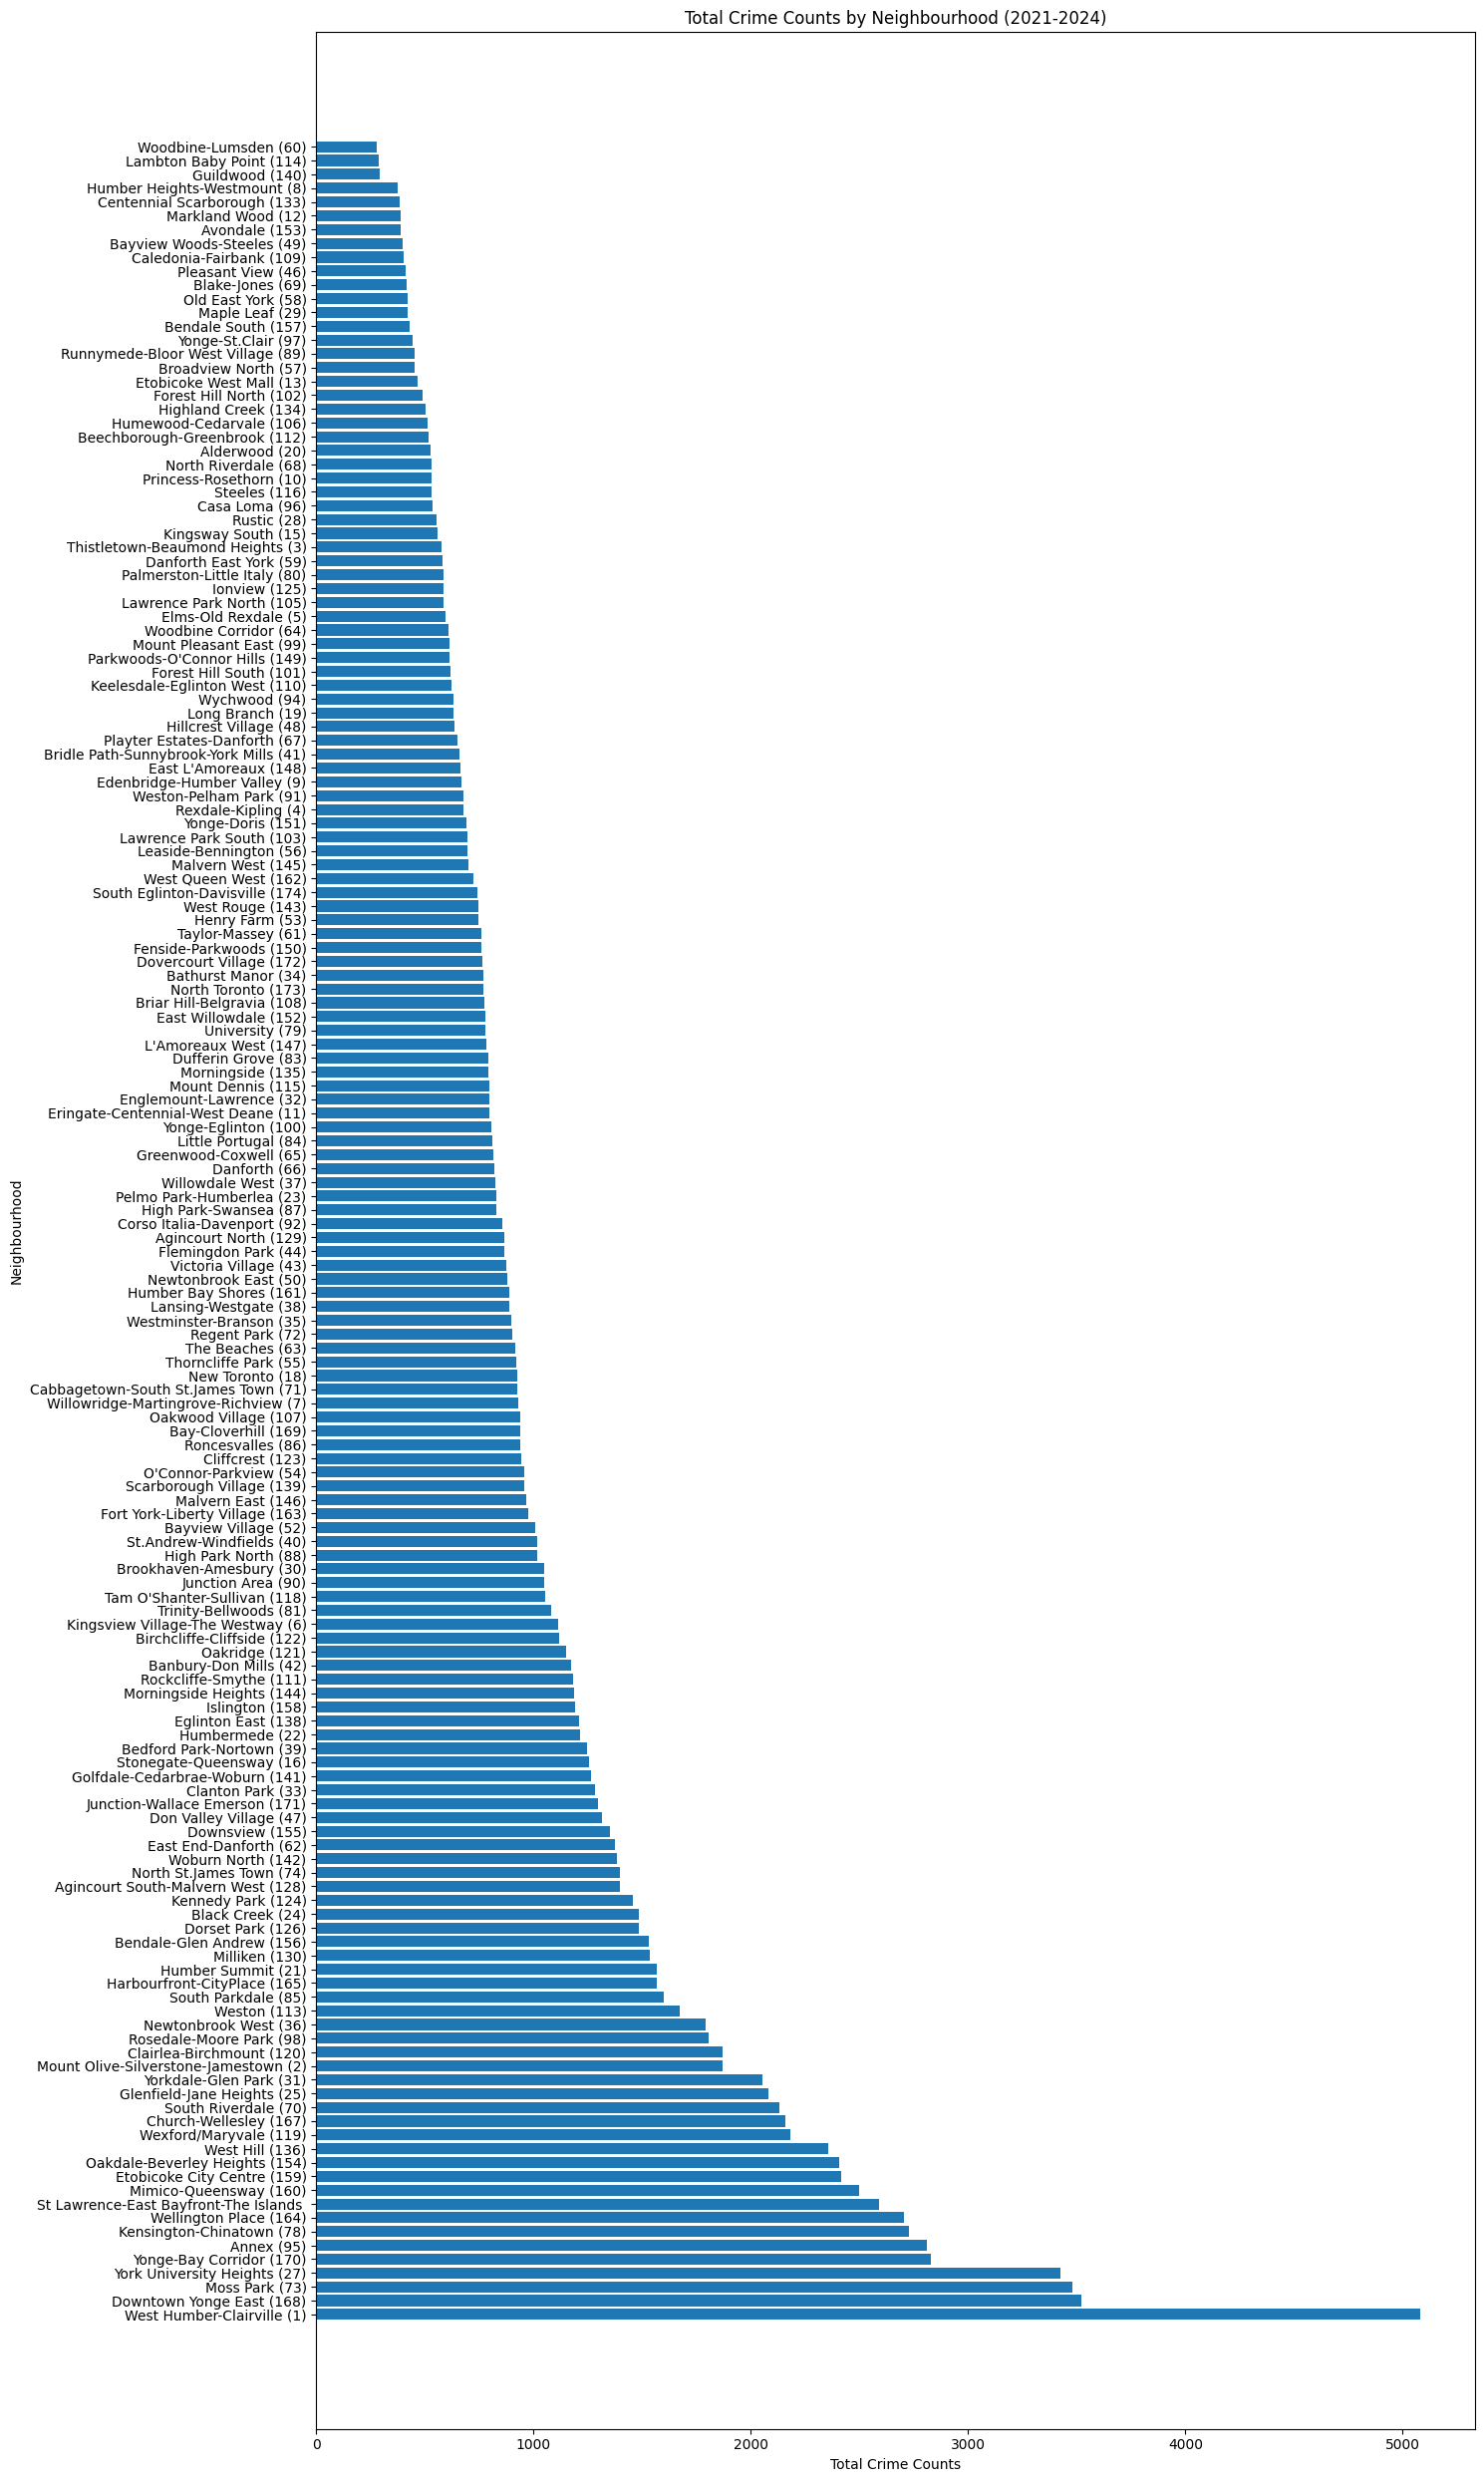

In [32]:
# generate a bar graph with HOOD_158 in X axis and Crime_counts as y.

import matplotlib.pyplot as plt

# Group by HOOD_158 and sum Crime_counts
hood_crime_counts = grouped_counts_all_crimes_with_zeros_short.groupby('HOOD_158', observed=False)['Crime_counts'].sum().reset_index()

# Merge with original dataframe to get NEIGHBOURHOOD_158
hood_crime_counts = hood_crime_counts.merge(df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates(), on='HOOD_158')

# Sort by Crime_counts in descending order and take the top N (optional)
hood_crime_counts = hood_crime_counts.sort_values(by='Crime_counts', ascending=False) # set this to `True`, to switch order

# Create the bar plot
plt.figure(figsize=(15, 25))
plt.barh(hood_crime_counts['NEIGHBOURHOOD_158'], hood_crime_counts['Crime_counts'])
plt.ylabel('Neighbourhood')
plt.xlabel('Total Crime Counts')
plt.title('Total Crime Counts by Neighbourhood (2021-2024)')
plt.tight_layout()
plt.show()

**As you can see above, this shows that a single neighbourhood heavily outweights all the other neigbourhoods in terms of crime count.**

### What does it mean?

The bar chart provides a visual summary of the total crime counts for each neighbourhood over the period from 2021 to 2024. The length of each bar directly represents the total number of crimes reported in that specific neighbourhood. The fact that "West Humber-Clairville (1)" has the longest bar indicates that it has the highest cumulative number of crime incidents during this period compared to all other neighbourhoods.

In [33]:
grouped_counts_all_crimes_with_zeros_short.Crime_counts.describe()

,Crime_counts
count,32864.000000
mean,5.201010
std,4.617836
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,48.000000


**Lets describe what each of these values mean:**


*   `count`: there are a total of `32,864` entries, which is 52 Weeks x 4 Years x 158 neighbourhoods entries. That gives us a count of crimes per each neighbourhood, per week.
*   `mean`: avg number of crimes per each neighbourhood, per week is `~5.2`
*   `std`: std deviation number of crimes per each neighbourhood, per week is `~4.62`. Which means there is a moderate amount variation in weekly crime count.
*   `min`: there are some neighbourhood weeks with `0` crime counts
*   `25%`: 25% of the neighbourhood-weeks had `2` or fewer crimes
*   `50%`: 50% of the neighbourhood-weeks had `4` or fewer crimes
*   `75%`: 75% of the neighbourhood-weeks had `7` or fewer crimes
*   `max`: The largest amount of crimes commited in a single neighbourhood in a single week is `48`.




In [34]:
# Find the maximum crime count
max_crime_count = grouped_counts_all_crimes_with_zeros_short['Crime_counts'].max()

# Filter the DataFrame to show rows with the maximum crime count
rows_with_max_crime = grouped_counts_all_crimes_with_zeros_short[grouped_counts_all_crimes_with_zeros_short['Crime_counts'] == max_crime_count]

# Display the row(s)
display(rows_with_max_crime)


# Get the HOOD_158 and WEEK_SEQ for the row with the maximum crime count
hood_with_max_crime = rows_with_max_crime['HOOD_158'].iloc[0]
week_with_max_crime = rows_with_max_crime['WEEK_SEQ'].iloc[0]

# Filter the original df_mci DataFrame to show rows that match the neighbourhood and week
detailed_max_crime_data = df_mci[(df_mci['HOOD_158'] == hood_with_max_crime) &
                                 (df_mci['WEEK_SEQ'] == week_with_max_crime)]

# Display the filtered data
display(detailed_max_crime_data)
detailed_max_crime_data['MCI_CATEGORY'].unique()


,HOOD_158,WEEK_SEQ,Crime_counts
127,001,128,48


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
344712,344713,GO-20231346933,6/12/2023 4:00:00 AM,5/30/2023 4:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.592844,43.680811,-8.860235e+06,5.416179e+06,6,889,128
344713,344714,GO-20231346692,6/12/2023 4:00:00 AM,6/5/2023 4:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.575623,43.701944,-8.858318e+06,5.419433e+06,6,889,128
344714,344715,GO-20231342056,6/12/2023 4:00:00 AM,6/10/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.565505,43.709148,-8.857192e+06,5.420542e+06,6,889,128
344749,344750,GO-20231342056,6/12/2023 4:00:00 AM,6/10/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.565505,43.709148,-8.857192e+06,5.420542e+06,6,889,128
344758,344759,GO-20231347016,6/12/2023 4:00:00 AM,3/2/2023 5:00:00 AM,2023,June,12,163,Monday,17,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.607455,43.743646,-8.861861e+06,5.425856e+06,6,889,128
344759,344760,GO-20231342388,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,8,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.597219,43.733205,-8.860722e+06,5.424247e+06,6,889,128
344780,344781,GO-20231342683,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.595509,43.686688,-8.860532e+06,5.417084e+06,6,889,128
344781,344782,GO-20231342824,6/12/2023 4:00:00 AM,6/11/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.599400,43.730879,-8.860965e+06,5.423889e+06,6,889,128
344782,344783,GO-20231342619,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,9,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.595571,43.686823,-8.860538e+06,5.417105e+06,6,889,128
344826,344827,GO-20231340525,6/12/2023 4:00:00 AM,6/12/2023 4:00:00 AM,2023,June,12,163,Monday,0,...,West Humber-Clairville (1),001,West Humber-Clairville (1),-79.569255,43.700495,-8.857609e+06,5.419209e+06,6,889,128


array(['Auto Theft', 'Break and Enter', 'Assault', 'Robbery'],
      dtype=object)

 > * I have taken the neighbourhood-week with the highest crime count and created a detailed view of that neighbourhood in that week (June 12th, 2023 - June 18th, 2023).
 * The point of interest is that, out of the five types of crime categories, all but one was committed.
 * The only type of crime excluded was `Theft Over` which refers to  *any theft over the value of $5000 (CAD)*.
 >
 > * **Why is this interesting?** When comparing this with the neighbourhood profiles, it would be interesting to see where in the avg. household income this neigbourhood will be.
 >* As per this data it suggests that `West Humber-Clairville (1)` would be in the lower end. (at least for the year 2023)

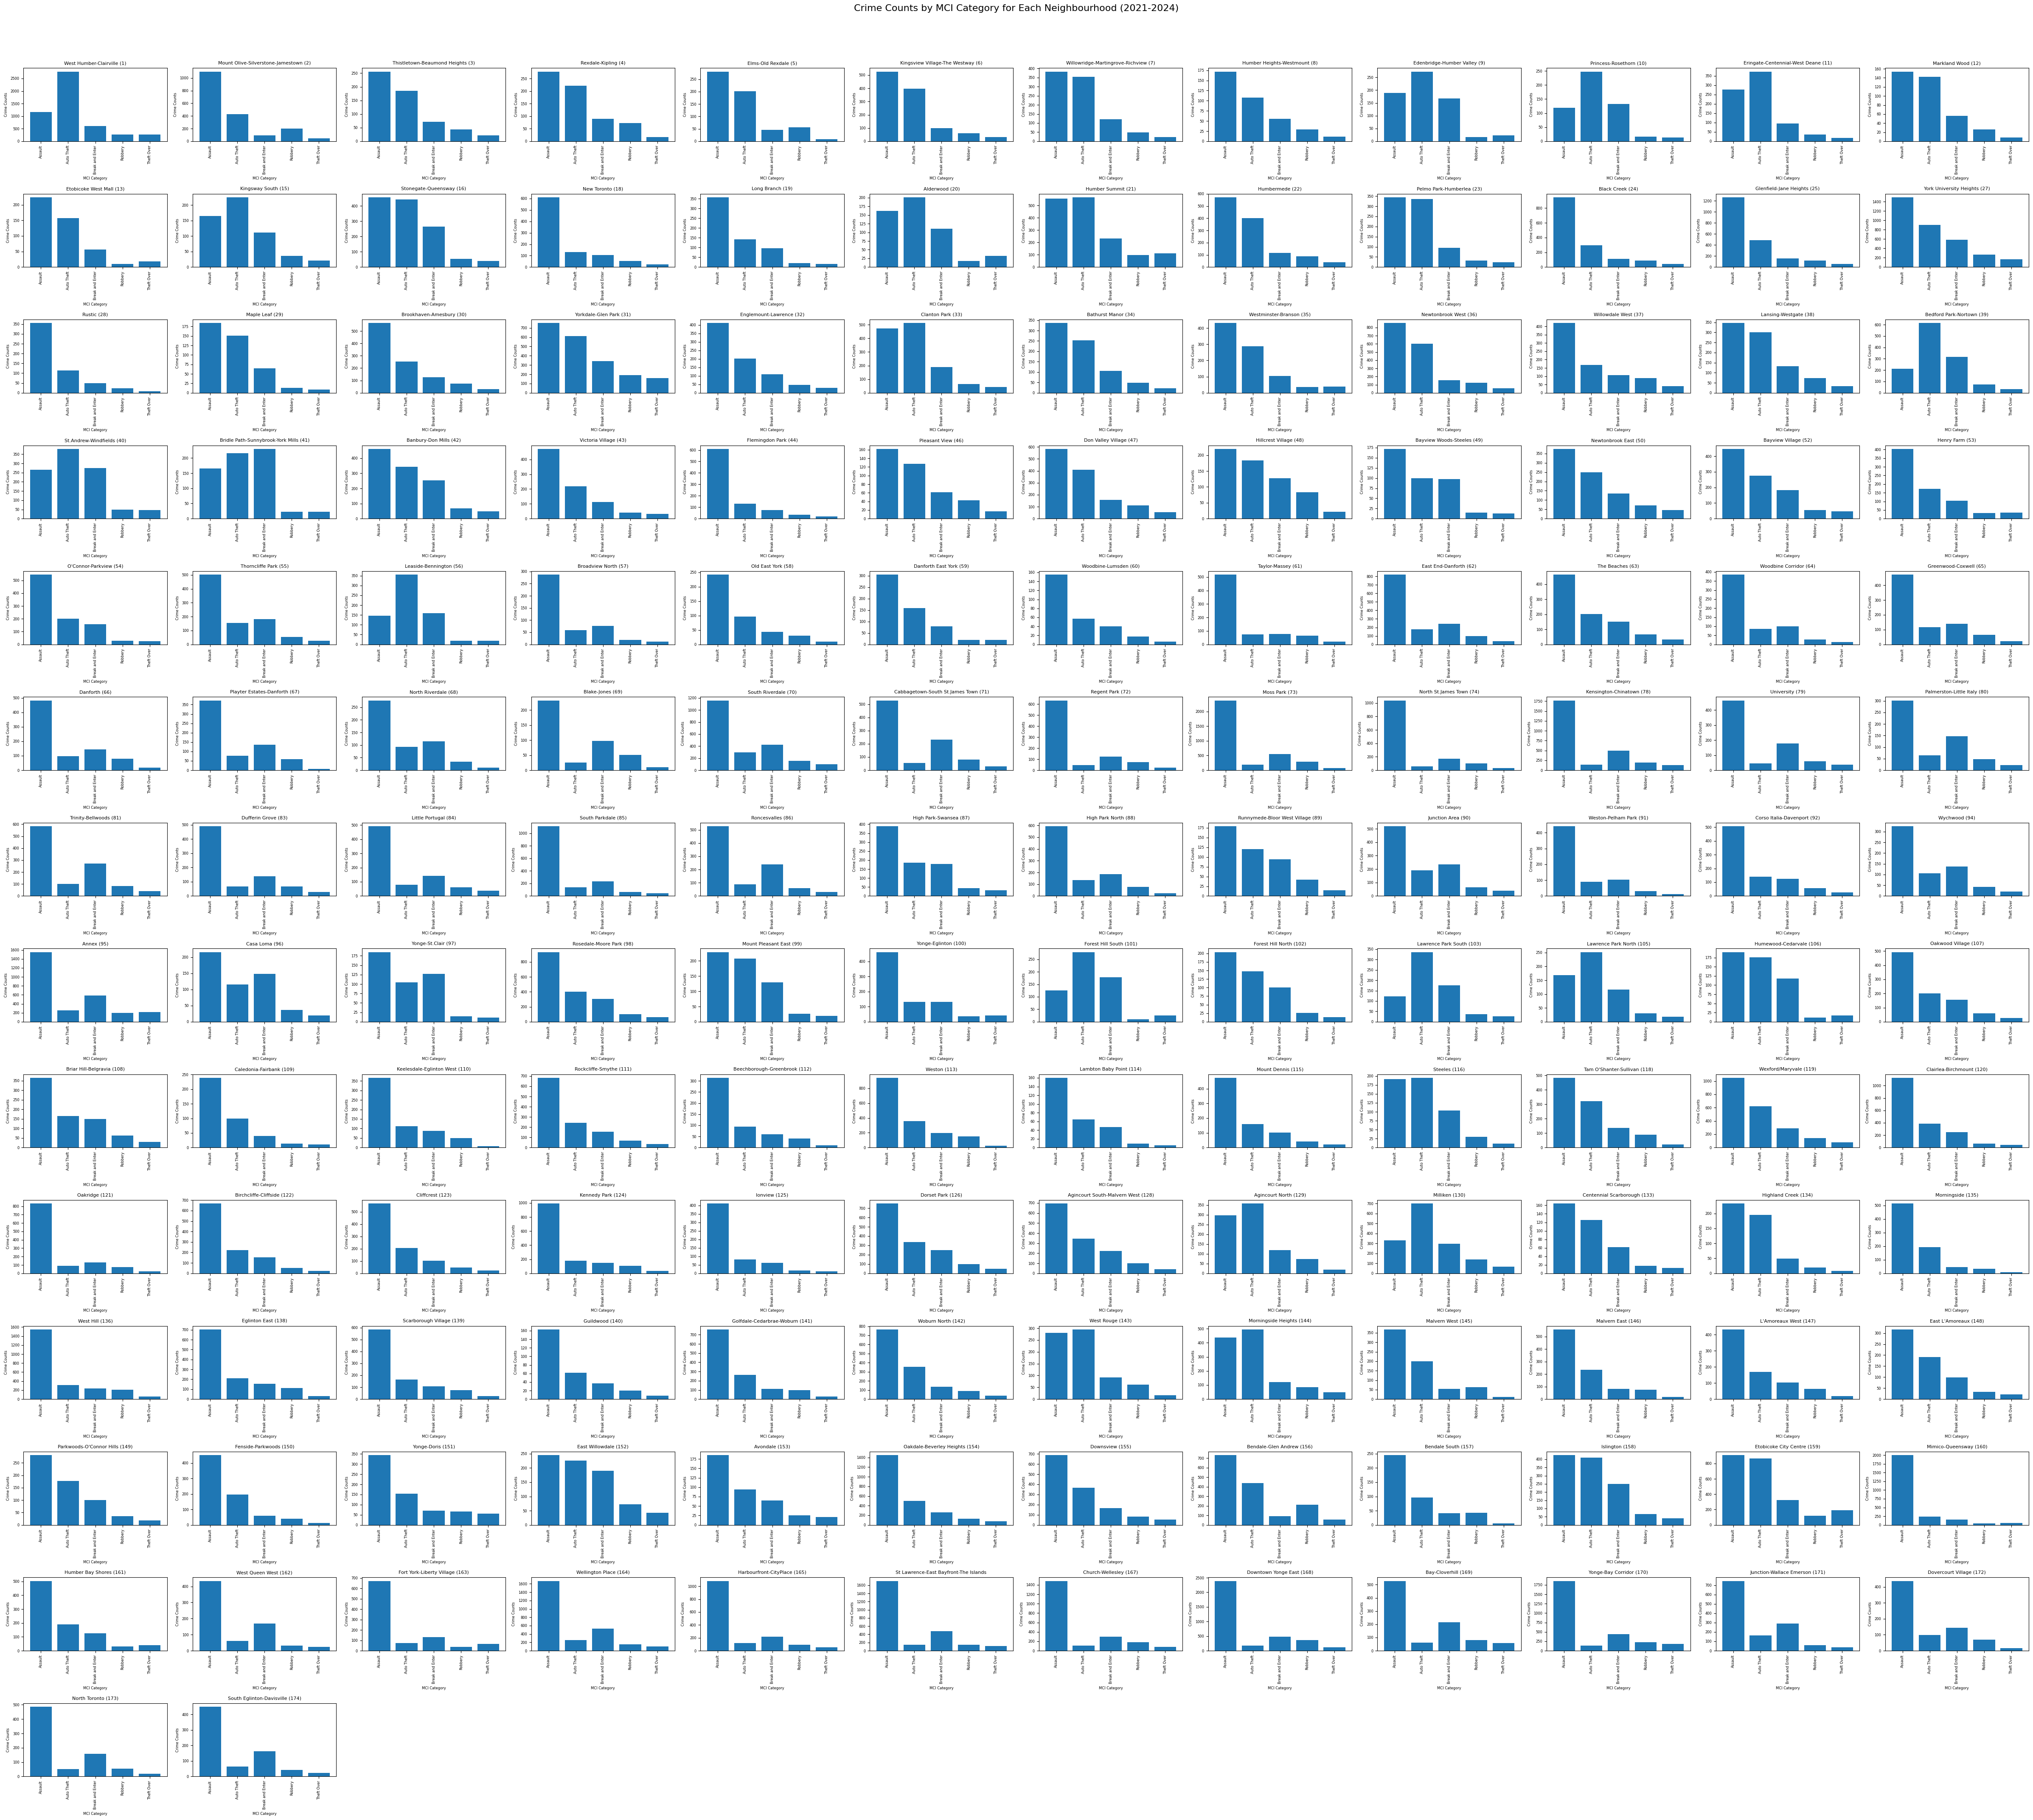

In [35]:
import matplotlib.pyplot as plt
# Group by HOOD_158 and MCI_CATEGORY and sum Crime_counts
hood_mci_crime_counts = grouped_counts_mci_categories_with_zeros_short.groupby(['HOOD_158', 'MCI_CATEGORY'], observed=False)['Crime_counts'].sum().reset_index()

# Get unique HOOD_158 values
unique_hoods = hood_mci_crime_counts['HOOD_158'].unique()

# Determine the number of rows and columns for the grid
num_hoods = len(unique_hoods)
cols = 12
rows = (num_hoods + cols - 1) // cols

# Create the figure and axes for the grid
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Add a main title to the figure
fig.suptitle('Crime Counts by MCI Category for Each Neighbourhood (2021-2024)', fontsize=16, y=1.02) # Add suptitle here

# Merge with original dataframe to get NEIGHBOURHOOD_158 names
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()

# Iterate through each unique hood and generate a bar graph
for i, hood in enumerate(unique_hoods):
  ax = axes[i]
  hood_data = hood_mci_crime_counts[hood_mci_crime_counts['HOOD_158'] == hood]

  # Get the corresponding neighbourhood name
  neighbourhood_name = hood_names[hood_names['HOOD_158'] == hood]['NEIGHBOURHOOD_158'].iloc[0]

  ax.bar(hood_data['MCI_CATEGORY'], hood_data['Crime_counts'])
  ax.set_title(f'{neighbourhood_name}', fontsize=8) # Set the title to the neighbourhood name and reduce font size
  ax.set_xlabel('MCI Category', fontsize=6) # Reduce font size
  ax.set_ylabel('Crime Counts', fontsize=6) # Reduce font size
  ax.tick_params(axis='x', rotation=90, labelsize=6) # Rotate and reduce font size for x-axis labels
  ax.tick_params(axis='y', labelsize=6) # Reduce font size for y-axis labels


# Hide any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



> **This confirms two assumptions:**
> 1.   The data needs to be normalized, as some neighbourhood's high crime count skew the others that aren't as high. This disparity makes direct comparisons of crime risk difficult without considering factors like population. Normalizing or standardizing the data (e.g., calculating crime rate per capita) would be a crucial next step for a fair comparison.
>
> 2.   The most common type of crime committed seems to be `Assault`. Let's prove this quantatively below.







In [36]:
# Calculate the total count for each MCI_CATEGORY across all neighbourhoods
total_counts = grouped_counts_mci_categories_with_zeros_short.groupby('MCI_CATEGORY', observed=False)['Crime_counts'].sum()

# Sort them to see which category has the highest overall number of incidents.
total_counts.sort_values(ascending=False)

# Display the sorted counts based on the MCI Category
print(total_counts)


MCI_CATEGORY
Assault            89397
Auto Theft         38113
Break and Enter    26079
Robbery            11266
Theft Over          6071
Name: Crime_counts, dtype: int64


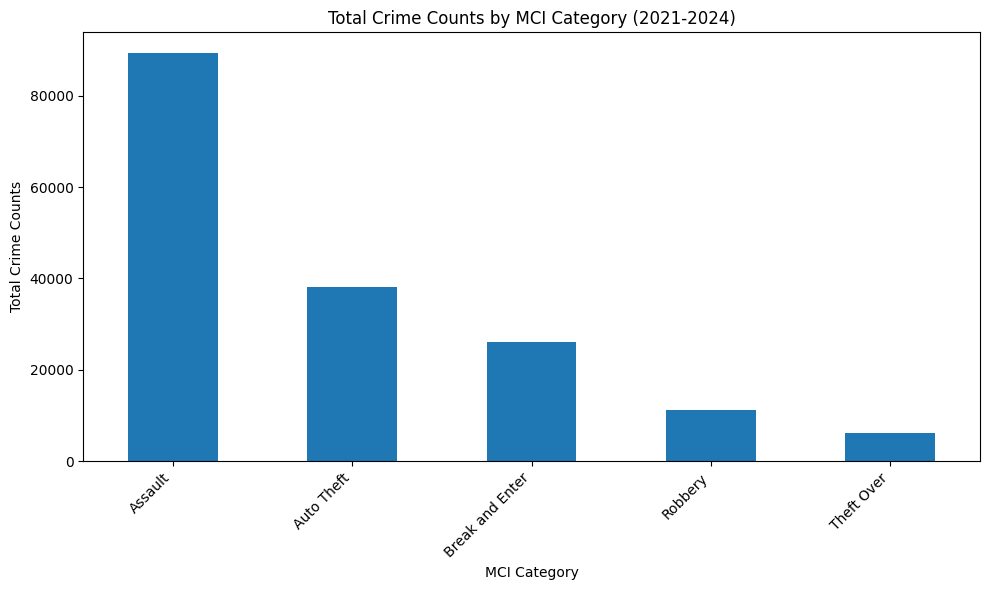

In [37]:
import matplotlib.pyplot as plt

# Sort the total counts in descending order for better visualization
sorted_total_counts = total_counts.sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
sorted_total_counts.plot(kind='bar')

plt.title('Total Crime Counts by MCI Category (2021-2024)')
plt.xlabel('MCI Category')
plt.ylabel('Total Crime Counts')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()



> As seen above, `Assault` far outweights any other type of crime. We will need to fix this with normalization.



## **10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**

In [38]:
# Lets import the neighbourhood-profiles-2021-158-model data
df_neighbourhood_profiles = pd.read_excel('neighbourhood-profiles-2021-158-model(1).xlsx')

# what is the shape of the data frame
df_neighbourhood_profiles.shape

(2603, 159)

In [39]:
df_neighbourhood_profiles.head(10)

,Neighbourhood Name,West Humber-Clairville,Mount Olive-Silverstone-Jamestown,Thistletown-Beaumond Heights,Rexdale-Kipling,Elms-Old Rexdale,Kingsview Village-The Westway,Willowridge-Martingrove-Richview,Humber Heights-Westmount,Edenbridge-Humber Valley,...,Harbourfront-CityPlace,St Lawrence-East Bayfront-The Islands,Church-Wellesley,Downtown Yonge East,Bay-Cloverhill,Yonge-Bay Corridor,Junction-Wallace Emerson,Dovercourt Village,North Toronto,South Eglinton-Davisville
0,Neighbourhood Number,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
1,TSNS 2020 Designation,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,...,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood
2,Total - Age groups of the population - 25% sam...,33300,31345,9850,10375,9355,22005,22445,10005,15190,...,28135,31285,22320,17700,16670,12645,23180,12380,15885,22735
3,0 to 14 years,4295,5690,1495,1575,1610,3915,3500,1370,2070,...,2065,2285,895,1055,745,970,3075,1365,1315,2190
4,0 to 4 years,1460,1650,505,505,440,1245,1065,395,520,...,1030,1045,495,480,370,500,1135,445,535,910
5,5 to 9 years,1345,1860,540,615,480,1325,1190,430,740,...,655,690,230,325,255,270,1020,430,390,670
6,10 to 14 years,1485,2175,455,455,685,1350,1240,540,815,...,385,550,175,245,120,200,925,490,390,610
7,15 to 64 years,23640,21490,6615,6950,6355,14385,13865,6245,9650,...,24540,25015,19315,14695,13815,10820,17200,9040,12780,17495
8,15 to 19 years,1860,2280,570,515,635,1245,1175,525,885,...,365,600,465,390,535,340,750,460,465,575
9,20 to 24 years,3175,2675,745,715,685,1605,1330,580,780,...,2250,1990,3010,2340,3810,1825,1185,640,960,1115


In [40]:
#Copy the transpose logic
# We want to tranpose the table such that the first column values become the header
df_neighbourhood_profiles = df_neighbourhood_profiles.transpose()

# Set the first row as the new header
new_header = df_neighbourhood_profiles.iloc[0]
df_neighbourhood_profiles = df_neighbourhood_profiles[1:]
df_neighbourhood_profiles.columns = new_header

# Display the first few rows with the correct headers
display(df_neighbourhood_profiles.head())

Neighbourhood Name,Neighbourhood Number,TSNS 2020 Designation,Total - Age groups of the population - 25% sample data,0 to 14 years,0 to 4 years,5 to 9 years,10 to 14 years,15 to 64 years,15 to 19 years,20 to 24 years,...,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,Children eligible for instruction in the minority official language,Children not eligible for instruction in the minority official language,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data",Children eligible for instruction in the minority official language,Eligible children who have been instructed in the minority official language at the primary or secondary level in Canada,Eligible children who have not been instructed in the minority official language at the primary or secondary level in Canada,Children not eligible for instruction in the minority official language
West Humber-Clairville,1,Not an NIA or Emerging Neighbourhood,33300,4295,1460,1345,1485,23640,1860,3175,...,1665,2935,5430,410,5020,3875,335,255,75,3540
Mount Olive-Silverstone-Jamestown,2,Neighbourhood Improvement Area,31345,5690,1650,1860,2175,21490,2280,2675,...,1145,2965,7285,510,6780,5540,395,245,145,5145
Thistletown-Beaumond Heights,3,Neighbourhood Improvement Area,9850,1495,505,540,455,6615,570,745,...,395,635,1860,180,1685,1325,120,75,45,1205
Rexdale-Kipling,4,Not an NIA or Emerging Neighbourhood,10375,1575,505,615,455,6950,515,715,...,425,775,1910,135,1770,1370,90,75,25,1275
Elms-Old Rexdale,5,Neighbourhood Improvement Area,9355,1610,440,480,685,6355,635,685,...,355,675,2015,95,1920,1520,70,60,10,1445


In [41]:
#Rename columns with duplicate names
cols=pd.Series(df_neighbourhood_profiles.columns)
for dup in df_neighbourhood_profiles.columns[df_neighbourhood_profiles.columns.duplicated(keep=False)]:
    cols[df_neighbourhood_profiles.columns.get_loc(dup)] = ([dup + '.' + str(d_idx)
                                     if d_idx != 0
                                     else dup
                                     for d_idx in range(df_neighbourhood_profiles.columns.get_loc(dup).sum())]
                                    )
df_neighbourhood_profiles.columns=cols
dfnp_selection = df_neighbourhood_profiles[['Total - Age groups of the population - 25% sample data']]
dfnp_selection = dfnp_selection.rename(columns={'Total - Age groups of the population - 25% sample data': 'POP_TOTAL'})
dfnp_selection['Neighbourhood_Number'] = df_neighbourhood_profiles[['Neighbourhood Number']]
dfnp_selection['POP_AGE_GROUP_0_14'] = df_neighbourhood_profiles[['  0 to 14 years.1']]
dfnp_selection['POP_AGE_GROUP_15_64'] = df_neighbourhood_profiles[['  15 to 64 years.1']]
dfnp_selection['POP_AGE_GROUP_65_'] = df_neighbourhood_profiles[['  65 years and over.1']]
dfnp_selection['POP_AVG_AGE'] = df_neighbourhood_profiles[['Average age of the population']]
dfnp_selection['POP_MED_AGE'] = df_neighbourhood_profiles[['Median age of the population']]
dfnp_selection['MARRIED_%'] = df_neighbourhood_profiles['  Married or living common-law'] / df_neighbourhood_profiles['Total - Marital status for the total population aged 15 years and over - 25% sample data']
dfnp_selection['POP_GOV_SUPP_SHARE'] = df_neighbourhood_profiles[['  Government transfers (%)']]
dfnp_selection['AVG_HHOLD_SIZE'] = df_neighbourhood_profiles[['Average household size']]
dfnp_selection['AVG_TOT_HHOLD_INC'] = df_neighbourhood_profiles[['  Average total income of household in 2020 ($)']]
dfnp_selection['OWNER_HHOLDS_%'] = df_neighbourhood_profiles['  Owner'] / df_neighbourhood_profiles['Total - Private households by tenure - 25% sample data']
dfnp_selection['DW_W_CONDO_STATUS_%'] = df_neighbourhood_profiles['  Condominium'] / df_neighbourhood_profiles['Total - Occupied private dwellings by condominium status - 25% sample data']
dfnp_selection['HHOLDS_UNSUIT_HOU_%'] = df_neighbourhood_profiles['  Not suitable'] / df_neighbourhood_profiles['Total - Private households by housing suitability - 25% sample data']
dfnp_selection['DW_REQ_MAJ_REPAIR_%'] = df_neighbourhood_profiles['  Major repairs needed'] / df_neighbourhood_profiles['Total - Occupied private dwellings by dwelling condition - 25% sample data']
dfnp_selection['SCTI_RAT_GT30_%'] = df_neighbourhood_profiles['  Spending 30% or more of income on shelter costs'] / df_neighbourhood_profiles['Total - Owner and tenant households with household total income greater than zero, in non-farm, non-reserve private dwellings by shelter-cost-to-income ratio - 25% sample data']
dfnp_selection['HHOLD_OWN_MRTG_HOLD_%'] = df_neighbourhood_profiles[['  % of owner households with a mortgage']]
dfnp_selection['HHOLD_OWN_SCTI_GT30_%'] = df_neighbourhood_profiles[['  % of owner households spending 30% or more of its income on shelter costs']]
dfnp_selection['AVG_DW_VAL'] = df_neighbourhood_profiles[['  Average value of dwellings ($)']]
dfnp_selection['HHOLDS_IN_SUBS_HOUS_%'] = df_neighbourhood_profiles[['  % of tenant households in subsidized housing']] / 100
dfnp_selection['HHOLDS_OWN_AVG_MNTH_COST'] = df_neighbourhood_profiles[['  Average monthly shelter costs for owned dwellings ($)']]
dfnp_selection['HHOLDS_RENT_AVG_MNTH_COST'] = df_neighbourhood_profiles[['  Average monthly shelter costs for rented dwellings ($)']]
dfnp_selection['AVG_FAM_SIZE'] = df_neighbourhood_profiles[['Average size of census families']]
dfnp_selection['ONE_PAR_FAM_%'] = df_neighbourhood_profiles['  Total one-parent families'] / df_neighbourhood_profiles['Total number of census families in private households - 25% sample data']
dfnp_selection['AVG_NUM_CH_PER_FAM'] = df_neighbourhood_profiles[['Average number of children in census families with children']]
dfnp_selection['HHOLD_FIRST_LANG_EN_%'] = df_neighbourhood_profiles['  English'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_FR_%'] = df_neighbourhood_profiles['  French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_ENFR_%'] = df_neighbourhood_profiles['  English and French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_OTH_%'] = df_neighbourhood_profiles['  Neither English nor French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['POP_NONCITIZ_%'] = df_neighbourhood_profiles['  Not Canadian citizens'] / df_neighbourhood_profiles['Total - Citizenship for the population in private households - 25% sample data']
dfnp_selection['POP_NON_IMMIGR_%'] = df_neighbourhood_profiles['  Non-immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_IMMIGR_%'] = df_neighbourhood_profiles['  Immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_TEMP_RES_%'] = df_neighbourhood_profiles['  Non-permanent residents'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['PARTICIP_RATE'] = df_neighbourhood_profiles[['Participation rate']]
dfnp_selection['UNEMPLOY_RATE'] = df_neighbourhood_profiles[['Unemployment rate']]
dfnp_selection['POP_NO_EDUC_%'] = df_neighbourhood_profiles['  No certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_HIGH_SCH_EDUC_%'] = df_neighbourhood_profiles['  High (secondary) school diploma or equivalency certificate.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_POSTSEC_EDUC_%'] = df_neighbourhood_profiles['  Postsecondary certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['COMMUTE_CAR_%'] = df_neighbourhood_profiles['  Car, truck or van'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_TRANSIT_%'] = df_neighbourhood_profiles['  Public transit'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_WALK_%'] = df_neighbourhood_profiles['  Walked'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_CYCLE_%'] = df_neighbourhood_profiles['  Bicycle'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_OTHER_%'] = df_neighbourhood_profiles['  Other method'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_LT_30_MIN_%'] = (df_neighbourhood_profiles['  Less than 15 minutes'] + df_neighbourhood_profiles['  15 to 29 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_30_59_MIN_%'] = (df_neighbourhood_profiles['  30 to 44 minutes'] + df_neighbourhood_profiles['  45 to 59 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_GT_59_MIN_%'] = df_neighbourhood_profiles['  60 minutes and over'] / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_5_6_AM_%'] = df_neighbourhood_profiles['  Between 5 a.m. and 5:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_6_7_AM_%'] = df_neighbourhood_profiles['  Between 6 a.m. and 6:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_7_8_AM_%'] = df_neighbourhood_profiles['  Between 7 a.m. and 7:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_8_9_AM_%'] = df_neighbourhood_profiles['  Between 8 a.m. and 8:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_9_AM_noon_%'] = df_neighbourhood_profiles['  Between 9 a.m. and 11:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_noon_5_AM_%'] = df_neighbourhood_profiles['  Between 12 p.m. and 4:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection.head(5)

scalingColumns = ['POP_AGE_GROUP_0_14','POP_AGE_GROUP_15_64','POP_AGE_GROUP_65_','POP_AVG_AGE','POP_MED_AGE','MARRIED_%','AVG_HHOLD_SIZE','AVG_TOT_HHOLD_INC',
                  'AVG_DW_VAL','HHOLDS_OWN_AVG_MNTH_COST','HHOLDS_RENT_AVG_MNTH_COST','AVG_FAM_SIZE','AVG_NUM_CH_PER_FAM'];


In [42]:
df_neighbourhood_profiles.shape

(158, 2603)

In [43]:
# Check for null values in each column and sum them
null_counts = df_neighbourhood_profiles.isnull().sum()

# Display the columns with their null counts
print(null_counts[null_counts > 0])

Series([], dtype: int64)


In [44]:
# Select the Neighbourhood Number and Total Population columns
df_population = df_neighbourhood_profiles[['Neighbourhood Number', 'Total - Age groups of the population - 25% sample data']].copy()

# Rename the population column for clarity
df_population = df_population.rename(columns={'Total - Age groups of the population - 25% sample data': 'Population_2021'})

# Display the first few rows of the new DataFrame
display(df_population.head())

Neighbourhood Name,Neighbourhood Number,Population_2021
West Humber-Clairville,1,33300
Mount Olive-Silverstone-Jamestown,2,31345
Thistletown-Beaumond Heights,3,9850
Rexdale-Kipling,4,10375
Elms-Old Rexdale,5,9355


In [45]:
# Convert 'Neighbourhood Number' to string and pad with leading zeros to match 'HOOD_158' format
df_population['Neighbourhood Number'] = df_population['Neighbourhood Number'].astype(str).str.zfill(3)

# Now attempt the merge again with the corrected 'Neighbourhood Number' format
df_crime_population = grouped_counts_all_crimes_with_zeros_short.merge(
    df_population,
    left_on='HOOD_158',  # Column in grouped_counts_all_crimes_with_zeros_short
    right_on='Neighbourhood Number',  # Column in df_population
    how='inner' # Use an inner merge to keep only matching neighbourhoods
)

# Drop the redundant 'Neighbourhood Number' column after merging
df_crime_population = df_crime_population.drop('Neighbourhood Number', axis=1)

# Display the first few rows and shape of the merged DataFrame
display(df_crime_population.head())
print(df_crime_population.shape)

,HOOD_158,WEEK_SEQ,Crime_counts,Population_2021
0,001,1,19,33300
1,001,2,11,33300
2,001,3,12,33300
3,001,4,20,33300
4,001,5,12,33300


(32864, 4)


In [46]:
# Calculate the crime rate per 1,000 people
df_crime_population['Crime_Rate_Per_1000'] = (df_crime_population['Crime_counts'] / df_crime_population['Population_2021']) * 1000

# Display the first few rows with the new crime rate column
display(df_crime_population.head())

,HOOD_158,WEEK_SEQ,Crime_counts,Population_2021,Crime_Rate_Per_1000
0,001,1,19,33300,0.570571
1,001,2,11,33300,0.33033
2,001,3,12,33300,0.36036
3,001,4,20,33300,0.600601
4,001,5,12,33300,0.36036


In [47]:
import pandas as pd
import numpy as np
from scipy.stats import variation
from scipy.fft import fft, fftfreq

# 1) Load & rename
crime_df = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'Crime_counts':'Count'})

# 2) Merge population & cast to numeric
df_population['Population_2021'] = (
    pd.to_numeric(df_population['Population_2021'], errors='coerce')
    .fillna(0)
    .astype(float)
)
crime_df = (
    crime_df
    .merge(df_population[['Neighbourhood Number','Population_2021']],
           left_on='HOOD_158', right_on='Neighbourhood Number', how='left')
    .drop('Neighbourhood Number', axis=1)
)

# 3) Ensure numeric & fill
for col in ['Count','Population_2021']:
    crime_df[col] = (
        pd.to_numeric(crime_df[col], errors='coerce')
        .fillna(0)
        .astype(float)
    )

# 4) Compute per‑capita rate
crime_df['Crime_Rate_Per_1000'] = (
    (crime_df['Count'] / crime_df['Population_2021']) * 1000
).fillna(0).astype(float)

# 5) Build full grid and fill
all_hoods      = crime_df['HOOD_158'].unique()
all_weeks      = crime_df['OCC_WEEK_SEQ'].unique()
all_categories = crime_df['MCI_CATEGORY'].unique()

full_idx = pd.MultiIndex.from_product(
    [all_hoods, all_weeks, all_categories],
    names=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY']
)
panel = (
    full_idx
    .to_frame(index=False)
    .merge(crime_df, on=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY'], how='left')
)

panel['Count'] = panel['Count'].fillna(0).astype(float)
panel['Population_2021'] = (
    panel
    .groupby('HOOD_158', observed=True)['Population_2021']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(0)
    .astype(float)
)
panel['Crime_Rate_Per_1000'] = (
    (panel['Count'] / panel['Population_2021']) * 1000
).fillna(0).astype(float)

# ─── Special Case Handling ───
# 1) Zero‑population flag
zero_pop_hoods = panel.loc[panel['Population_2021']==0, 'HOOD_158'].unique()
panel['zero_population_flag'] = panel['HOOD_158'].isin(zero_pop_hoods)

# 2) Volatility + zero‑crime flag
volatility = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(
        cv_counts = ('Count', lambda x: variation(x) if x.mean()!=0 else np.nan),
        cv_rates  = ('Crime_Rate_Per_1000', lambda x: variation(x) if x.mean()!=0 else np.nan),
    )
    .reset_index()
)
volatility['zero_crime_flag'] = volatility['cv_counts'].isna()

# 6) Map real date → quarter
week_map = (
    df_mci_occ[['OCC_WEEK_SEQ','OCC_DATE']]
    .drop_duplicates()
    .assign(OCC_DATE=lambda df: pd.to_datetime(df['OCC_DATE']))
)
week_map['OCC_YEAR']    = week_map['OCC_DATE'].dt.year
week_map['OCC_QUARTER'] = week_map['OCC_DATE'].dt.quarter

panel = panel.merge(week_map, on='OCC_WEEK_SEQ', how='left')

# 7) Seasonality: mean rate by true calendar quarter
seasonality = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR','OCC_QUARTER'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack(['OCC_QUARTER','OCC_YEAR'])
)
seasonality.columns = [
    f"mean_rate_Q{q}_{y}"
    for q,y in seasonality.columns
]
seasonality = seasonality.reset_index()

# 8) Volatility: CV on counts & rates
volatility = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(
        cv_counts = ('Count', lambda x: variation(x) if x.mean()!=0 else np.nan),
        cv_rates  = ('Crime_Rate_Per_1000', lambda x: variation(x) if x.mean()!=0 else np.nan),
    )
    .reset_index()
)

# 9) Trend: YoY % change on annual average rate
annual_rates = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack('OCC_YEAR')
)
for prev, nxt in zip(annual_rates.columns[:-1], annual_rates.columns[1:]):
    annual_rates[f"YoY_Rate_Change_{prev}_vs_{nxt}"] = (
        (annual_rates[nxt] - annual_rates[prev]) / annual_rates[prev] * 100
    )
trend = annual_rates.filter(like="YoY_Rate_Change").reset_index()

# 10) Concentration: HHI on rates
concentration = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)['Crime_Rate_Per_1000']
    .apply(lambda x: np.sum((x/x.sum())**2) if x.sum()>0 else 0)
    .rename('hhi_rate_concentration')
    .reset_index()
)

# 11) Merge all temporal features
temp_feats = (
    seasonality
    .merge(volatility,    on=['HOOD_158','MCI_CATEGORY'])
    .merge(trend,         on=['HOOD_158','MCI_CATEGORY'])
    .merge(concentration, on=['HOOD_158','MCI_CATEGORY'])
)

# 12) Fourier features with peak month
weekly_totals = panel.groupby(['HOOD_158','OCC_WEEK_SEQ'], observed=True)['Crime_Rate_Per_1000'].sum().reset_index()
fourier_list = []
for hood, grp in weekly_totals.groupby('HOOD_158', observed=True):
    rates = grp.sort_values('OCC_WEEK_SEQ')['Crime_Rate_Per_1000'].values
    N     = len(rates)
    yf    = fft(rates)
    xf    = fftfreq(N)
    feats = {'HOOD_158': hood}
    for label, freq in [('yearly',1/52), ('half',1/26)]:
        idx = np.argmin(np.abs(xf - freq))
        if 0 < idx < N/2:
            amp   = np.abs(yf[idx]) * 2 / N
            phase = np.angle(yf[idx]) % (2*np.pi)
            months = 12 if label=='yearly' else 6
            feats[f'{label}_amp']        = amp
            feats[f'{label}_peak_month'] = (phase/(2*np.pi)) * months
    fourier_list.append(feats)
fourier_df = pd.DataFrame(fourier_list)

# 13) Final merge
final_features_df = temp_feats.merge(fourier_df, on='HOOD_158', how='left')

print("Final Temporal Features (vectorized, warnings silenced):")
display(final_features_df.head())
print("\nShape:", final_features_df.shape)


Final Temporal Features (vectorized, warnings silenced):


,HOOD_158,MCI_CATEGORY,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,...,cv_counts,cv_rates,YoY_Rate_Change_2021_vs_2022,YoY_Rate_Change_2022_vs_2023,YoY_Rate_Change_2023_vs_2024,hhi_rate_concentration,yearly_amp,yearly_peak_month,half_amp,half_peak_month
0,001,Assault,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,...,0.482614,0.482614,9.176471,19.558190,2.558136,0.000844,0.180156,1.991694,0.069645,3.774705
1,001,Auto Theft,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,...,0.410393,0.410393,57.888698,6.413517,-21.659058,0.000800,0.180156,1.991694,0.069645,3.774705
2,001,Break and Enter,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,...,0.743875,0.743875,31.773050,61.571582,-27.713036,0.001063,0.180156,1.991694,0.069645,3.774705
3,001,Robbery,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,...,1.197488,1.197488,33.243968,9.657948,-19.120670,0.001666,0.180156,1.991694,0.069645,3.774705
4,001,Theft Over,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,...,0.863733,0.863733,5.076142,30.676329,-5.619022,0.001195,0.180156,1.991694,0.069645,3.774705



Shape: (790, 28)


In [48]:
# ─── Merge Special‑Case Flags into final_features_df ───

# 1) Zero‑population flag (per neighbourhood)
if 'zero_population_flag' not in panel:
    panel['zero_population_flag'] = panel['Population_2021'] == 0

hood_flags = panel[['HOOD_158','zero_population_flag']].drop_duplicates()

# 2) Zero‑crime flag (per neighbourhood×category)
#   True if that hood/category never had any incidents (Count sum == 0)
vol_flags = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(zero_crime_flag=('Count', lambda x: x.sum() == 0))
    .reset_index()
)

# 3) Merge both flags in
final_features_df = (
    final_features_df
    .merge(hood_flags, on='HOOD_158', how='left')
    .merge(vol_flags,  on=['HOOD_158','MCI_CATEGORY'], how='left')
)

# 4) Check
print("Features with flags:")
display(final_features_df.head())
print("\nNew shape:", final_features_df.shape)


Features with flags:


,HOOD_158,MCI_CATEGORY,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,...,YoY_Rate_Change_2021_vs_2022,YoY_Rate_Change_2022_vs_2023,YoY_Rate_Change_2023_vs_2024,hhi_rate_concentration,yearly_amp,yearly_peak_month,half_amp,half_peak_month,zero_population_flag,zero_crime_flag
0,001,Assault,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,...,9.176471,19.558190,2.558136,0.000844,0.180156,1.991694,0.069645,3.774705,False,False
1,001,Auto Theft,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,...,57.888698,6.413517,-21.659058,0.000800,0.180156,1.991694,0.069645,3.774705,False,False
2,001,Break and Enter,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,...,31.773050,61.571582,-27.713036,0.001063,0.180156,1.991694,0.069645,3.774705,False,False
3,001,Robbery,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,...,33.243968,9.657948,-19.120670,0.001666,0.180156,1.991694,0.069645,3.774705,False,False
4,001,Theft Over,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,...,5.076142,30.676329,-5.619022,0.001195,0.180156,1.991694,0.069645,3.774705,False,False



New shape: (790, 30)


In [50]:
import re
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1) Identify crime‐block columns as before
season_cols = [c for c in final_features_df.columns if re.match(r"mean_rate_Q[1-4]_(2021|2022|2023)$", c)]
trend_cols  = [c for c in final_features_df.columns
               if re.match(r"YoY_Rate_Change_\d{4}_vs_\d{4}$", c) and not c.endswith("_vs_2024")]
vol_cols    = ['cv_counts','cv_rates']
concen_cols = ['hhi_rate_concentration']
fourier_cols= [c for c in final_features_df.columns if c.endswith('_amp') or c.endswith('_peak_month')]

crime_features = season_cols + trend_cols + vol_cols + concen_cols + fourier_cols

# 2) Extract and clean infinities → NaN
X_crime = final_features_df[crime_features].replace([np.inf, -np.inf], np.nan)

# 3) Impute NaN → 0 (interpreted as “no change” for YOY and “no variability” for CV)
X_crime_filled = X_crime.fillna(0)

# 4) Fit StandardScaler on the cleaned crime block
scaler_crime = StandardScaler()
scaler_crime.fit(X_crime_filled)

# 5) Transform & append z‑score columns
scaled = scaler_crime.transform(X_crime_filled)
for idx, feat in enumerate(crime_features):
    final_features_df[f"{feat}_z"] = scaled[:, idx]

# 6) Quick sanity check
print("Crime features (cleaned) + their z‑scores:")
display(final_features_df[crime_features + [f"{f}_z" for f in crime_features]].head())


Crime features (cleaned) + their z‑scores:


,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,mean_rate_Q1_2023,mean_rate_Q2_2023,...,mean_rate_Q4_2023_z,YoY_Rate_Change_2021_vs_2022_z,YoY_Rate_Change_2022_vs_2023_z,cv_counts_z,cv_rates_z,hhi_rate_concentration_z,yearly_amp_z,yearly_peak_month_z,half_amp_z,half_peak_month_z
0,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,0.117117,0.182820,...,1.788358,-0.361787,-0.155047,-1.273626,-1.273626,-0.753783,-0.251469,-1.491947,-1.005275,0.798976
1,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,0.653320,0.542851,...,3.757873,0.095610,-0.304046,-1.339701,-1.339701,-0.764643,-0.251469,-1.491947,-1.005275,0.798976
2,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,0.098765,0.119130,...,0.625101,-0.149610,0.321189,-1.034599,-1.034599,-0.699824,-0.251469,-1.491947,-1.005275,0.798976
3,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,0.060727,0.031680,...,-0.437875,-0.135798,-0.267269,-0.619589,-0.619589,-0.551531,-0.251469,-1.491947,-1.005275,0.798976
4,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,0.044044,0.030030,...,-0.116977,-0.400288,-0.029019,-0.924941,-0.924941,-0.667377,-0.251469,-1.491947,-1.005275,0.798976


# Clean up Column Names

In [51]:
# ─── A) Clean up column names ───
df_neighbourhood_profiles.columns = (
    df_neighbourhood_profiles.columns
        .str.strip()                                # remove leading/trailing spaces
        .str.replace(r'\s+', ' ', regex=True)       # collapse multiple spaces
)

# just to verify:
print(df_neighbourhood_profiles.columns.tolist())


['Neighbourhood Number', 'TSNS 2020 Designation', 'Total - Age groups of the population - 25% sample data', '0 to 14 years', '0 to 4 years', '5 to 9 years', '10 to 14 years', '15 to 64 years', '15 to 19 years', '20 to 24 years', '25 to 29 years', '30 to 34 years', '35 to 39 years', '40 to 44 years', '45 to 49 years', '50 to 54 years', '55 to 59 years', '60 to 64 years', '65 years and over', '65 to 69 years', '70 to 74 years', '75 to 79 years', '80 to 84 years', '85 years and over', '85 to 89 years', '90 to 94 years', '95 to 99 years', '100 years and over', 'Total - Distribution (%) of the population by broad age groups - 25% sample data', '0 to 14 years.1', '15 to 64 years.1', '65 years and over.1', '85 years and over.1', 'Average age of the population', 'Median age of the population', 'Total - Persons in private households - 25% sample data', 'Total - Persons in census families', 'Married spouses or common-law partners', 'Parents in one-parent families', 'Children', 'In a two-parent f

# Socio‑Economic: Select Core Indicators

In [52]:
# ─── B) Subset, Impute & Prune Socio‑Economic Indicators ───
import numpy as np

# 1) pick only the direct, easy‑to‑explain indicators
candidate_cols = [
    'Neighbourhood Number',
    'Median total income in 2020 among recipients ($)',
    'Unemployment rate',
    'Average household size',
    '% of owner households spending 30% or more of its income on shelter costs',
    '% in core housing need'
]

socio = (
    df_neighbourhood_profiles[candidate_cols]
      .rename(columns={'Neighbourhood Number':'HOOD_158'})
)

# 2) drop any feature with >50% missing, then median‑impute the rest
missing_pct = socio.drop('HOOD_158', axis=1).isna().mean()
keep_cols   = missing_pct[missing_pct < 0.5].index.tolist()

socio = socio[['HOOD_158'] + keep_cols].copy()
socio[keep_cols] = socio[keep_cols].fillna(socio[keep_cols].median())

# 3) prune away one of any two features whose |corr|>0.8
corr  = socio[keep_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.8).any()]
socio = socio.drop(columns=to_drop)

print("→ retained socio‑econ features:", socio.columns.tolist())


# ─── C) Scale to Z‑Scores ───
from sklearn.preprocessing import StandardScaler

feat_cols = [c for c in socio.columns if c!='HOOD_158']
scaler    = StandardScaler()

socio_z = socio.copy()
socio_z[feat_cols] = scaler.fit_transform(socio_z[feat_cols])

print("→ sample z‑scored profiles:")
display(socio_z.head())


→ retained socio‑econ features: ['HOOD_158', 'Median total income in 2020 among recipients ($)', 'Average household size', '% of owner households spending 30% or more of its income on shelter costs', '% in core housing need']
→ sample z‑scored profiles:


/tmp/ipython-input-52-790577691.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  socio[keep_cols] = socio[keep_cols].fillna(socio[keep_cols].median())


Neighbourhood Name,HOOD_158,Median total income in 2020 among recipients ($),Average household size,% of owner households spending 30% or more of its income on shelter costs,% in core housing need
West Humber-Clairville,1,-0.823400,1.533931,-0.410600,-0.346633
Mount Olive-Silverstone-Jamestown,2,-1.216176,1.773182,0.535710,1.240503
Thistletown-Beaumond Heights,3,-0.901955,1.294681,-0.174023,-0.086059
Rexdale-Kipling,4,-0.823400,0.337677,-1.146619,-0.607208
Elms-Old Rexdale,5,-0.744845,1.055430,-0.147736,0.316648


In [53]:
final_features_df

,HOOD_158,MCI_CATEGORY,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,...,mean_rate_Q4_2023_z,YoY_Rate_Change_2021_vs_2022_z,YoY_Rate_Change_2022_vs_2023_z,cv_counts_z,cv_rates_z,hhi_rate_concentration_z,yearly_amp_z,yearly_peak_month_z,half_amp_z,half_peak_month_z
0,001,Assault,0.121788,0.119790,0.165165,0.152109,0.184184,0.123420,0.144601,0.158963,...,1.788358,-0.361787,-0.155047,-1.273626,-1.273626,-0.753783,-0.251469,-1.491947,-1.005275,0.798976
1,001,Auto Theft,0.193861,0.224400,0.344366,0.381904,0.402736,0.417450,0.451103,0.538582,...,3.757873,0.095610,-0.304046,-1.339701,-1.339701,-0.764643,-0.251469,-1.491947,-1.005275,0.798976
2,001,Break and Enter,0.043043,0.053460,0.046677,0.088458,0.074741,0.057420,0.084867,0.088458,...,0.625101,-0.149610,0.321189,-1.034599,-1.034599,-0.699824,-0.251469,-1.491947,-1.005275,0.798976
3,001,Robbery,0.022689,0.037950,0.032315,0.029704,0.053720,0.027060,0.050268,0.032641,...,-0.437875,-0.135798,-0.267269,-0.619589,-0.619589,-0.551531,-0.251469,-1.491947,-1.005275,0.798976
4,001,Theft Over,0.025359,0.029370,0.029704,0.045045,0.025359,0.033990,0.038843,0.037864,...,-0.116977,-0.400288,-0.029019,-0.924941,-0.924941,-0.667377,-0.251469,-1.491947,-1.005275,0.798976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,174,Assault,0.084060,0.099087,0.070759,0.085580,0.104587,0.116971,0.108528,0.082711,...,0.377463,-0.245218,-0.567433,-0.975225,-0.975225,-0.682856,-0.815460,2.440793,-0.949731,0.437321
786,174,Auto Theft,0.012218,0.004350,0.007171,0.025339,0.011729,0.012084,0.006693,0.003347,...,-0.732961,-0.742533,0.789174,0.192350,0.192350,-0.060992,-0.815460,2.440793,-0.949731,0.437321
787,174,Break and Enter,0.058158,0.030451,0.020080,0.036335,0.025414,0.029001,0.010040,0.012909,...,-0.057306,-0.886141,0.608011,-0.520038,-0.520038,-0.505654,-0.815460,2.440793,-0.949731,0.437321
788,174,Robbery,0.003421,0.000000,0.010040,0.015777,0.027857,0.004834,0.005259,0.013387,...,-0.826965,0.244737,-1.285710,1.039370,1.039370,0.733431,-0.815460,2.440793,-0.949731,0.437321


In [54]:
def compute_features(up_to_year):
    import numpy as np
    import pandas as pd

    # ─── 0) Discover your real “occurrence date” column ───
    def find_date_col(df, df_name):
        # look for anything with “date” in its name
        candidates = [c for c in df.columns if 'DATE' in c.upper()]
        if not candidates:
            raise KeyError(
                f"compute_features: I couldn’t find a date column in {df_name}. "
                f"Here are its columns:\n{df.columns.tolist()}"
            )
        # if there are multiple, you may choose the first or add logic
        return candidates[0]

    # make a local copy so we don’t clobber your global DF
    df_occ = df_mci_occ.copy()
    occ_date_col = find_date_col(df_occ, 'df_mci_occ')
    df_occ['OCC_DATE'] = pd.to_datetime(df_occ[occ_date_col], errors='coerce')

    panel = df_crime_population.copy()
    panel_date_col = find_date_col(panel, 'df_crime_population')
    panel['OCC_DATE'] = pd.to_datetime(panel[panel_date_col], errors='coerce')

    # ─── 1) Merge Socio‑Econ Profiles ───
    full_df = (
        final_features_df
        .merge(socio_z, on="HOOD_158", how="left")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[
            'Median total income in 2020 among recipients ($)',
            'yearly_amp',            # your Fourier amp
            'yearly_peak_month'      # your Fourier peak month
        ])
    )

    # ─── 2) Annual crime rates up to up_to_year ───
    df2 = df_occ[df_occ['OCC_DATE'].dt.year <= up_to_year].copy()
    df2['OCC_YEAR'] = df2['OCC_DATE'].dt.year

    annual_cr = (
        df2
        .groupby(['HOOD_158','OCC_YEAR','MCI_CATEGORY'])
        .size().reset_index(name='Annual_Crime_Count')
        .merge(
            df_population[['Neighbourhood Number','Population_2021']],
            left_on='HOOD_158', right_on='Neighbourhood Number', how='left'
        ).drop('Neighbourhood Number', axis=1)
    )
    annual_cr['Annual_Crime_Rate_Per_1000'] = (
        (annual_cr['Annual_Crime_Count'] / annual_cr['Population_2021'])
        .replace([np.inf,-np.inf], 0).fillna(0) * 1000
    )

    df_with_rate = df2.merge(
        annual_cr[
            ['HOOD_158','OCC_YEAR','MCI_CATEGORY','Annual_Crime_Rate_Per_1000']
        ],
        on=['HOOD_158','OCC_YEAR','MCI_CATEGORY'], how='left'
    )

    # ─── 3) Neighborhood‐level average rate ───
    panel2 = panel[panel['OCC_DATE'].dt.year <= up_to_year]
    hood_rate = (
        panel2
        .groupby('HOOD_158', observed=False)['Crime_Rate_Per_1000']
        .mean().reset_index()
        .merge(
            df_occ[['HOOD_158','NEIGHBOURHOOD_158']].drop_duplicates(),
            on='HOOD_158'
        )
    )

    # ─── 4) Category‐level average rate ───
    df_cat = (
        grouped_counts_mci_categories_with_zeros_short
        .merge(df_population[['Neighbourhood Number','Population_2021']],
               left_on='HOOD_158', right_on='Neighbourhood Number', how='inner')
        .drop('Neighbourhood Number', axis=1)
    )
    df_cat['Crime_Rate_Category_Per_1000'] = (
        (df_cat['Crime_counts'] / df_cat['Population_2021'])
        .replace([np.inf,-np.inf], 0).fillna(0) * 1000
    )
    avg_cat = (
        df_cat
        .groupby(['HOOD_158','MCI_CATEGORY'], observed=False)['Crime_Rate_Category_Per_1000']
        .mean().reset_index()
        .merge(
            df_occ[['HOOD_158','NEIGHBOURHOOD_158']].drop_duplicates(),
            on='HOOD_158'
        )
    )

    # ─── 5) Overall weekly trend ───
    overall_trend = (
        panel2
        .groupby('WEEK_SEQ', observed=False)['Crime_Rate_Per_1000']
        .mean().reset_index()
    )

    return {
        'features': full_df,
        'annual_crime_rate': annual_cr,
        'df_mci_with_rate': df_with_rate,
        'hood_crime_rate': hood_rate,
        'average_crime_rate_category': avg_cat,
        'overall_crime_trend': overall_trend,
    }


In [55]:
# build your train/test sets
data_2023 = compute_features(2023)
#data_2024 = compute_features(2024)

# e.g. to plot the top‐neighbourhood bar chart:
import matplotlib.pyplot as plt

top20 = data_2023['hood_crime_rate'].nlargest(20, 'Crime_Rate_Per_1000')
plt.figure(figsize=(8,10))
plt.barh(top20['NEIGHBOURHOOD_158'], top20['Crime_Rate_Per_1000'])
plt.xlabel('Avg Crime Rate per 1,000')
plt.title('Top 20 Neighbourhoods (2021–2023)')
plt.tight_layout()
plt.show()


KeyError: "compute_features: I couldn’t find a date column in df_crime_population. Here are its columns:\n['HOOD_158', 'WEEK_SEQ', 'Crime_counts', 'Population_2021', 'Crime_Rate_Per_1000']"